### Importing the libraries

In [211]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [212]:
tf.__version__

'2.16.1'

## Part 1 - Data Preprocessing

### Preprocessing the Training set

In [213]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)
training_set = train_datagen.flow_from_directory('dataset/training_set',
                                                 target_size = (128,128),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

Found 8317 images belonging to 2 classes.


In [214]:
training_set.classes

array([0, 0, 0, ..., 1, 1, 1])

### Preprocessing the Test set

In [215]:
test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory('dataset/test_set',
                                            target_size = (128,128),
                                            batch_size = 32,
                                            class_mode = 'binary')

Found 1400 images belonging to 2 classes.


In [216]:
test_set.classes

array([0, 0, 0, ..., 1, 1, 1])

## Part 2 - Building the CNN

### Initialising the CNN

In [217]:
cnn = tf.keras.models.Sequential()

### Step 1 - Convolution

In [218]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu',input_shape=[128,128,3]))

E:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 2 - Pooling

In [219]:
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

### Adding a second convolutional layer

In [220]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

### Step 3 - Flattening

In [221]:
cnn.add(tf.keras.layers.Flatten())

### Step 4 - Full Connection

In [222]:
cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))

### Step 5 - Output Layer

In [223]:
cnn.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

## Part 3 - Training the CNN

### Compiling the CNN

In [224]:
cnn.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [225]:
cnn.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 61, 61, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,801 (14.10 MB)

 Trainable params: 3,696,801 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

### Training the CNN on the Training set and evaluating it on the Test set

In [226]:
epochs=20
history=cnn.fit(x=training_set,validation_data=test_set,epochs=epochs)

Epoch 1/15


E:\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


260/260 ━━━━━━━━━━━━━━━━━━━━ 225s 826ms/step - accuracy: 0.6366 - loss: 0.6983 - val_accuracy: 0.8614 - val_loss: 0.3825
Epoch 2/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 92s 348ms/step - accuracy: 0.8017 - loss: 0.4168 - val_accuracy: 0.8821 - val_loss: 0.3569
Epoch 3/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 86s 323ms/step - accuracy: 0.8418 - loss: 0.3549 - val_accuracy: 0.8557 - val_loss: 0.3705
Epoch 4/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 88s 335ms/step - accuracy: 0.8576 - loss: 0.3160 - val_accuracy: 0.8286 - val_loss: 0.4079
Epoch 5/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 91s 345ms/step - accuracy: 0.8773 - loss: 0.2839 - val_accuracy: 0.8400 - val_loss: 0.4267
Epoch 6/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 92s 348ms/step - accuracy: 0.8979 - loss: 0.2414 - val_accuracy: 0.8771 - val_loss: 0.2856
Epoch 7/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 94s 353ms/step - accuracy: 0.9091 - loss: 0.2119 - val_accuracy: 0.8750 - val_loss: 0.3007
Epoch 8/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 87s 329ms/step - accuracy: 0.9225 - loss: 0.1899 - va

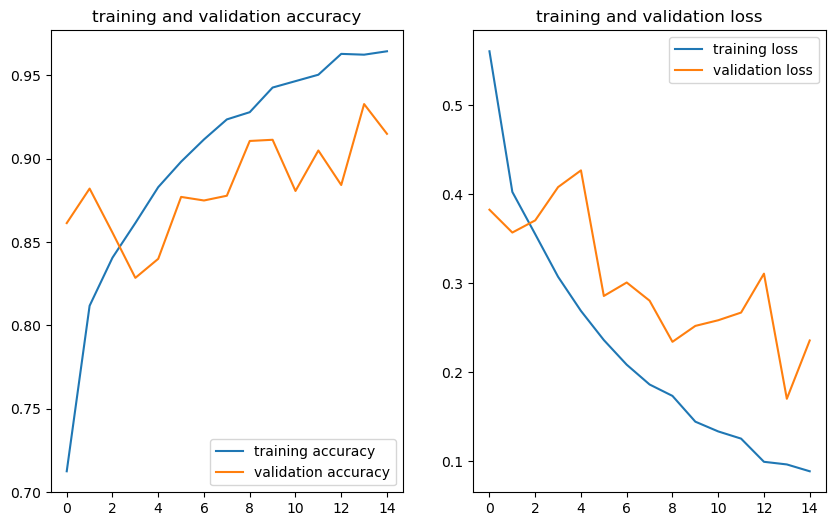

In [227]:
import matplotlib.pyplot as plt

acc=history.history['accuracy']
val_acc=history.history['val_accuracy']

loss=history.history['loss']
val_loss=history.history['val_loss'] 

epochs_range=range(epochs)

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label='training accuracy')
plt.plot(epochs_range,val_acc,label='validation accuracy')
plt.legend(loc='lower right')
plt.title('training and validation accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,loss,label='training loss')
plt.plot(epochs_range,val_loss,label='validation loss')
plt.legend(loc='upper right')
plt.title('training and validation loss')
plt.show()

In [228]:
import numpy as np
from keras.preprocessing import image
test_image = image.load_img('dataset/single_prediction/n_b_m_3.png', target_size = (128,128,32))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result = cnn.predict(test_image)
training_set.class_indices
if result[0][0] == 0:
  prediction = 'begnin'
else :
  prediction = 'malignent'


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


In [210]:
print(prediction)

malignent


Random (chance) Prediction : AUROC = 0.500
Random Forest: AUROC = 0.937


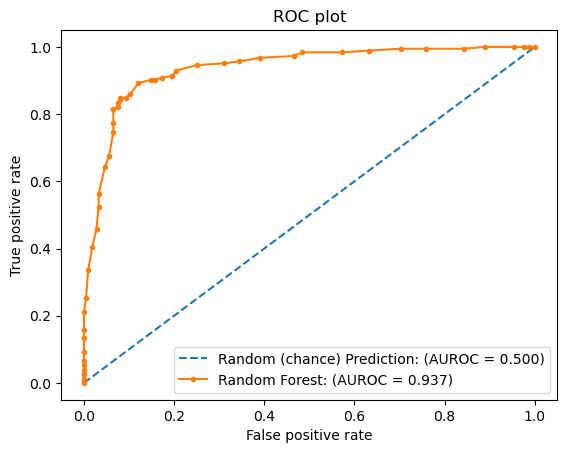

In [202]:
from sklearn.datasets import make_classification
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

x, y = make_classification(n_samples=2000, n_classes=2, n_features=10, random_state=42)

random_state = np.random.RandomState(0)
n_samples, n_features = x.shape
x = np.c_[x, random_state.randn(n_samples, 200 * n_features)]

from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train a classifier 
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

nb = GaussianNB()
nb.fit(x_train, y_train)

r_probs = [0 for _ in range(len(y_test))]
rf_probs = rf.predict_proba(x_test)
nb_probs = rf.predict_proba(x_test)

rf_probs = rf_probs[:, 1]

r_fpr,r_tpr, _ = roc_curve(y_test, r_probs) 
rf_fpr,rf_tpr, _ = roc_curve(y_test, rf_probs)

r_auc = roc_auc_score(y_test, r_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

print('Random (chance) Prediction : AUROC = %.3f' %(r_auc))
print('Random Forest: AUROC = %.3f' %(rf_auc))


plt.plot(r_fpr, r_tpr,linestyle='--', label='Random (chance) Prediction: (AUROC = %.3f)' % r_auc)
plt.plot(rf_fpr, rf_tpr, marker= '.', label='Random Forest: (AUROC = %.3f)' % rf_auc)


# Plot a ROC curve
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()#
plt.title('ROC plot')
plt.show()


In [203]:
from sklearn.metrics import classification_report
Y_pred = cnn.predict(training_set)
y_pred = np.argmax(Y_pred, axis=1)

print(classification_report(training_set.classes,y_pred))

254/254 ━━━━━━━━━━━━━━━━━━━━ 63s 247ms/step
              precision    recall  f1-score   support

           0       0.50      1.00      0.67      4074
           1       0.00      0.00      0.00      4042

    accuracy                           0.50      8116
   macro avg       0.25      0.50      0.33      8116
weighted avg       0.25      0.50      0.34      8116



E:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [204]:
from sklearn.metrics import classification_report
X_pred = cnn.predict(test_set)
x_pred = np.argmax(X_pred, axis=1)

print(classification_report(test_set.classes,x_pred))

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step
              precision    recall  f1-score   support

           0       0.56      1.00      0.71       500
           1       0.00      0.00      0.00       400

    accuracy                           0.56       900
   macro avg       0.28      0.50      0.36       900
weighted avg       0.31      0.56      0.40       900



E:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Normalized confusion matrix


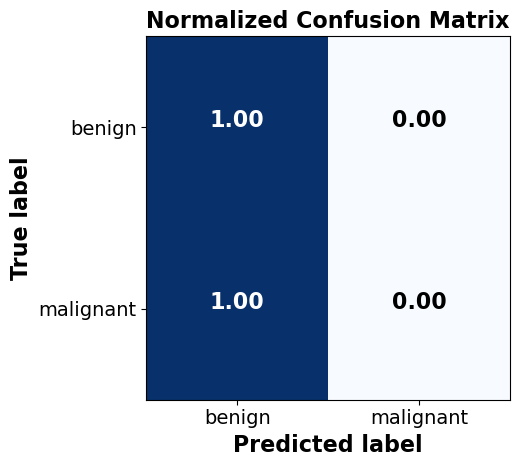

In [137]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
        
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, weight='bold', fontsize=16)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=14)
    plt.yticks(tick_marks, classes, fontsize=14)
    
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center", fontsize=16, weight='bold',
                 color="white" if cm[i, j] > thresh else "black")
        
    plt.tight_layout()
    plt.ylabel('True label', fontsize=16, weight='bold')
    plt.xlabel('Predicted label', fontsize=16, weight='bold')

# Assuming you have your ground truth and predictions ready
cnf_matrix = confusion_matrix(training_set.classes,y_pred)
cnf_matrix = confusion_matrix(test_set.classes,x_pred)
np.set_printoptions(precision=2)

# Plot normalized confusion matrix
plt.figure(figsize=(5,5))
plot_confusion_matrix(cnf_matrix, classes=[benign', 'malignant'], normalize=True, title='Normalized Confusion Matrix')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

b=[[n],
   [m]] 

plt.matshow(b)

cancer = ['begnin','malignent']
x_pos = np.arange(len(cancer))
plt.xticks(x_pos,cancer)

y_pos = np.arange(len(cancer))
plt.xticks(y_pos,cancer)

plt.show()